In [ ]:
! pip install numpy
! pip install matplotlib
! pip install pandas
! pip install scipy
! pip install statsmodels

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import glob

In [6]:
# read science data line by line, parse json, and store in a list
# filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
# filename = 'batch_20240410_1435_turkPilot2.scienceData.jsonl'
# filename = 'revision_202504/batch_20250421_1915_pilot.scienceData.jsonl'
# filename = 'revision_202504/batch_20250429_1536_pilot.scienceData.jsonl'
# filename = 'revision_202508/batch_20250903_1711_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl'
# filenames = [
#     'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl'
# ]
filenames = glob.glob('revision_202509/batch_*.scienceData.jsonl')
print("Filenames to process:", filenames)
raw = []

for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                raw.append(parsed)


data = pd.DataFrame()
data["treatment"] = [row["treatment"]["name"] for row in raw]
data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]
data["sampleId"] = [row["sampleId"] for row in raw]
data["gameId"] = [row["gameId"][-6:] for row in raw]

# parse connection info into columns
connection_info = pd.DataFrame([row['connectionInfo'] for row in raw])
data = pd.concat([data, connection_info], axis=1)

# Parse browser info into columns
browser_info = pd.DataFrame([row['browserInfo'] for row in raw])
data = pd.concat([data, browser_info], axis=1)

# Parse QC survey into columns
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in raw])
data = pd.concat([data, QC], axis=1)

# Parse participation data into columns
data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times into columns
# these are taken from the submit button timings
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in raw])
columns = ["time_"+"_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]

labeling_times = [col for col in submit_times.columns if "labeling" in col]
submit_times[labeling_times] = submit_times[labeling_times].fillna(300) # fill missing labeling times with 5 minutes, the max

data = pd.concat([data, submit_times[labeling_times]], axis=1)

# # parse labels into columns
# def extract_word(cell):
#     for i in range(8):
#         cell = cell.replace(f"Image {i+1}:", "")
#     return cell.strip()

# def get_labels(row):
#     keys = ['prompt_labeling_1a', 'prompt_labeling_1b', 'prompt_labeling_1c',
#             'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4']
#     labels = {}
#     for key in keys:
#         try:
#             raw_labels_for_round = row['prompts'][key]['value'].split("\n")
#             raw_labels_for_round = [extract_word(label) for label in raw_labels_for_round]
#             for i, word in enumerate(raw_labels_for_round):
#                 labels[key.replace("prompt_labeling_", "label_") + "_" + str(i)] = word
#         except (KeyError, TypeError, AttributeError):
#             continue

#     return labels
    
# labels = pd.DataFrame([get_labels(row) for row in raw])
# labels = labels[sorted(labels.columns)]
# data = pd.concat([data, labels], axis=1)

# Parse recall responses into columns
# standardize recall responses to lowercase and strip leading and trailing whitespace
recall = pd.DataFrame([{key: d['value'].lower().strip() for key, d in row['prompts'].items() if 'recall' in key} for row in raw])
recall.columns = [col.replace('prompt_recall_', 'recall_') for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("") # fill missing recall responses with empty string
data = pd.concat([data, recall], axis=1)

# # Compute total recall time
# total_recall_time = pd.DataFrame()
# for round in sorted(set([col.split("_")[1] for col in recall.columns])):
#     cols = [col for col in data.columns if "time_recall_"+round in col]
#     total_recall_time["time_recall_total_"+round] = data[cols].sum(axis=1)

# data = pd.concat([data, total_recall_time], axis=1)

# Compute matches (true/false) and merge into columns
matches = (data.groupby("gameId")[recall.columns].nunique() == 1) & (data.groupby("gameId")[recall.columns].count() == 2)  # binary did they match, and did they both participate?
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
data = pd.merge(left=data, right=matches, left_on="gameId", right_index=True)

# # Compute raw points and merge into columns (not used in the final analysis)
# points = pd.DataFrame()
# for round in sorted(set([col.split("_")[1] for col in matches.columns])):
#     cols_in_round = [col for col in  matches.columns if f"_{round}_" in col]
#     points["points_"+round] = matches[cols_in_round].sum(axis=1)*10 # each correct recall is worth 10 points
# data = pd.merge(left=data, right=points, left_on="gameId", right_index=True)

# find matched recalls (i.e., the actual words that were recalled the same)
matched_recalls = pd.DataFrame()
for match_col in [col for col in data.columns if "match_" in col]:
    recall_col = match_col.replace("match_", "recall_")
    matched_recall_col = match_col.replace("match_", "matched_recall_")
    data[matched_recall_col] = data[recall_col]*data[match_col] # mask out non-matches (they are empty strings)


# compute points only on unique labels
points_unique = pd.DataFrame()
for round in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [col for col in  data if f"matched_recall_{round}_" in col]
    data[f"points_unique_{round}"] = data[cols].replace("", np.nan).nunique(axis=1) * 10 # each correct recall is worth 10 points, don't count empty stings

# # compute scores excluding recall time
for round in sorted(set([col.split("_")[1] for col in matches.columns])):
    data[f"score_{round}"] = (data["points_unique_"+round] / data["time_labeling_"+round] * 60).round(2)  # score is points earned per minute of coordination time


# # # compute scores including recall time
# # scores_with_recall = pd.DataFrame()
# # for round in sorted(set([col.split("_")[1] for col in matches.columns])):
# #     total_time = data["time_labeling_"+round] + data["time_recall_total_"+round]
# #     scores_with_recall["score_with_recall_"+round] = (data["points_unique_"+round] / total_time * 60).round(2)  # score is points earned per minute of total time

# # data = pd.concat([data, scores_with_recall], axis=1)

# # sort data for easier viewing
# data = data.sort_values(by=['treatmentGroup', 'treatment', 'gameId']).reset_index(drop=True)


# filter groups with nonparticipation
data = data[data["num_reports"]<3]  # not missing from conversation
data['empty_recall_counts'] = (data[[col for col in  recall.columns]] == "").sum(axis=1)
data = data[data['empty_recall_counts'] < 10]  # participating in recall

print("condition counts:", data.groupby("treatment")["sampleId"].count())

data.to_csv("pilot_analysis_results.csv", index=False)

pd.options.display.max_rows = None
print(data.shape)

#data[data["gameId"] == raw[0]["gameId"][-6:]].T

use_conditions = ['schema', 'nonschema']
data[data["treatment"].isin(use_conditions)].sort_values(by=['treatmentGroup', 'treatment', 'gameId']).T


Filenames to process: ['revision_202509/batch_20251209_1551_pilot.scienceData.jsonl', 'revision_202509/batch_20251209_1914_pilot.scienceData.jsonl', 'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl', 'revision_202509/batch_20260106_2205_pilot.scienceData.jsonl', 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl', 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl', 'revision_202509/batch_20251006_1941_pilot.scienceData.jsonl', 'revision_202509/batch_20250915_2325_pilot.scienceData.jsonl']
condition counts: treatment
nonschema                    29
nonschema_black_and_white    16
nonschema_tangrams            8
schema                       28
schema_black_and_white       16
schema_nonschema              6
schema_tangrams              14
Name: sampleId, dtype: int64
(117, 165)


,16,17,57,58,95,98,82,83,44,46,...,51,54,59,64,80,81,75,77,71,72
treatment,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
treatmentGroup,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
sampleId,37837561-9529-477a-b8dd-f641f8765e4d,bd4e3570-652a-4e1f-8643-6719eb6a9c38,2854f232-4ea1-4eea-9a5c-404bbb3102e9,9f738f00-cff6-410a-85d8-da36b5c4764f,d1e7143f-4864-4498-843f-196820730bf4,d4c3cc1c-1171-4c7a-bd36-95b1d787300b,c88d0313-17ed-46c1-b71a-497216a266d2,43bc610d-8a32-4d94-814a-767a03aaa55e,9c11532a-270d-453a-bf01-54996b269071,08d18631-d4d8-4f0d-b566-2cb573b3159f,...,42ffb7f2-e462-4ce6-83d1-9b7b32e6702e,2a635e23-ab9a-4e33-bb89-0c60f816497f,35cb2f4e-0c74-4185-9826-d48743ba896f,29d82a96-503c-497f-a047-0abaac9b3271,0204802a-f5dd-4407-b84f-47eb858af386,588b9075-89b7-4e48-a950-716980a73141,b1d2fffe-fa95-4b4f-815e-a11c8f5ff99b,5f4bcd54-144e-488d-abb9-9116dc8d5745,9c65043d-ad4f-4189-a0c7-0086fec80922,aa4497b2-a98b-416e-8c1d-5d53fdc80914
gameId,ACFAK0,ACFAK0,B78GBJ,B78GBJ,C3XTXF,C3XTXF,CHGNHQ,CHGNHQ,D98JZ6,D98JZ6,...,JBMYEM,JBMYEM,KH7MPC,KH7MPC,PWNDE7,PWNDE7,RRAMXF,RRAMXF,VD27WJ,VD27WJ
country,US,GB,US,US,GB,GB,US,US,US,GB,...,CA,GB,GB,GB,CA,US,GB,US,CA,GB
timezone,America/Los_Angeles,Europe/London,America/Chicago,America/New_York,Europe/London,Europe/London,America/Los_Angeles,America/New_York,America/New_York,Europe/London,...,America/Vancouver,Europe/London,Europe/London,Europe/London,America/Toronto,America/New_York,Europe/London,America/New_York,America/Vancouver,Europe/London
isKnownVpn,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
timezoneOffset,-08:00,+00:00,-06:00,-05:00,+01:00,+01:00,-08:00,-05:00,-05:00,+00:00,...,-08:00,+00:00,+00:00,+00:00,-05:00,-05:00,+00:00,-05:00,-08:00,+00:00
isLikelyVpn,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
effectiveType,4g,4g,4g,4g,4g,4g,4g,4g,4g,4g,...,4g,4g,4g,4g,4g,4g,4g,4g,4g,4g


In [7]:
data[data["treatment"].isin(use_conditions)]['time_labeling_3']

0      168.176
3       72.919
6       73.481
7      198.234
8      192.690
10     178.907
16     237.384
17     235.118
18     142.869
19     142.192
22     153.792
23     238.400
24     152.390
25     237.817
44     111.895
46     102.188
48     130.537
49     132.724
50     299.532
51     135.667
52     280.824
53     166.317
54     134.796
55     165.972
57     140.150
58     141.194
59     154.639
60      69.293
61     214.528
62      69.371
63     219.858
64     153.254
65     217.679
66     243.923
67      89.908
68     221.230
69     119.727
70     118.647
71     102.113
72     102.788
73     126.623
74     190.733
75     103.939
76     125.013
77      96.385
78     233.590
79     228.060
80     173.217
81     172.027
82     239.301
83       0.000
95     154.941
96      80.981
97      79.771
98     154.533
103    181.075
104    181.248
Name: time_labeling_3, dtype: float64

In [9]:
data[data["time_labeling_3"] < 3].T

,83
treatment,nonschema
treatmentGroup,nonschema
sampleId,43bc610d-8a32-4d94-814a-767a03aaa55e
gameId,CHGNHQ
country,US
timezone,America/New_York
isKnownVpn,False
timezoneOffset,-05:00
isLikelyVpn,False
effectiveType,4g


In [50]:
data.groupby("gameId")[["time_labeling_3", "time_labeling_4"]].first() - data.groupby("gameId")[["time_labeling_3", "time_labeling_4"]].last()

,time_labeling_3,time_labeling_4
gameId,,
0A3Q33,1.402,0.000
0KG3W5,-1.816,-1.780
0RH6K8,-29.395,-24.233
0TZ5ZR,-0.334,0.628
1BK027,1.210,1.172
2SFPGH,-2.187,-0.185
2VRY0R,-0.732,-0.751
3EZ1YD,1.046,1.064
3FG866,0.504,0.507


In [11]:
data[['empty_recall_counts', 'num_reports']].max()

empty_recall_counts    4
num_reports            0
dtype: int64

In [13]:
data.groupby("treatment")[["points_unique_3", "points_unique_4", "time_labeling_3", "time_labeling_4", "score_3", "score_4"]].mean().loc[['nonschema', 'schema']]

,points_unique_3,points_unique_4,time_labeling_3,time_labeling_4,score_3,score_4
treatment,,,,,,
nonschema,71.724138,69.655172,183.155414,196.596448,inf,24.307586
schema,72.142857,47.857143,131.180464,189.564500,37.354286,17.948571


In [14]:
data.groupby("treatment")[["score_3", "score_4"]].count().loc[['nonschema', 'nonschema_black_and_white', 'schema', 'schema_black_and_white']]

,score_3,score_4
treatment,,
nonschema,29,29
nonschema_black_and_white,16,16
schema,28,28
schema_black_and_white,16,16


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_43304/3567621271.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")


Comments:
Participating in this study was super fun!
Thanks for the opportunity to participate in this study!
No
Nothing
no comment
my partner was very nice.
no
N/A
really enjoyable interesting study
no thank you
it was enjoyable
none
It was great fun!
no
I was the only doing this the person showed for a minute and never come back
no
I did not encounter technical problem during the experiment. 
I overthink things, so the instructions were probably easy, I just got hung up on the part about whether we allowed to reuse the same labels for different objects across rounds (I thought we could reuse them as long as it was not in the same round but thought it would be too confusing to use the same label for different objects, so we decided not to, or at least I said I preferred not to because I would likely confuse them.)
This was a lot of fun!
No
none
n/a
The research was very interesting, but it took much longer than expected.
No, thank you for letting me participate
My partner Nelson compl

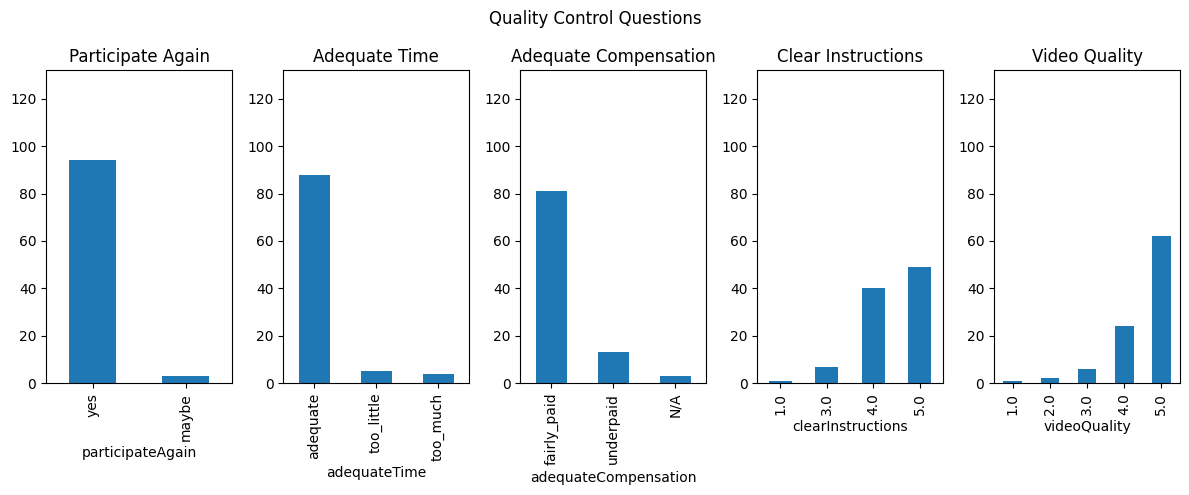

In [15]:
# Plot QC data

plt.figure(figsize=(12, 5))
plt.subplot(1,5,1)
QC["participateAgain"].value_counts().plot(kind='bar', title="Participate Again")
plt.ylim(0, len(QC))

plt.subplot(1,5,2)
# QC["adequateTime"].value_counts().loc[["too_little", "adequate", "too_much"]].plot(kind='bar', title="Adequate Time")
QC["adequateTime"].value_counts().plot(kind='bar', title="Adequate Time")
plt.ylim(0, len(QC))

plt.subplot(1,5,3)
QC["adequateCompensation"].value_counts().plot(kind='bar', title="Adequate Compensation")
plt.ylim(0, len(QC))

plt.subplot(1,5,4)
QC["clearInstructions"].value_counts().sort_index().plot(kind='bar', title="Clear Instructions")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.subplot(1,5,5)
QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.suptitle("Quality Control Questions")
plt.tight_layout()

print("Comments:")
for text in QC["textExpansion"]:
    if str(text) != "nan":
        print(text)

print("\nTechnical Issues:")
for text in QC["textExpansion"]:
    if str(text) != "nan":
        print(text)


# QC

# Power Calculations

### Round 3

In [52]:

# use all data for round 3 analysis
# grouped_3 = data.groupby("treatmentGroup")
grouped_3 = data[data["treatment"].isin(["schema", "nonschema"])].groupby("treatment")
means_3 = grouped_3[["points_unique_3", "time_labeling_3",  "score_3"]].mean()
sds_3 = grouped_3[["points_unique_3", "time_labeling_3", "score_3"]].std()
ns_3 = grouped_3[["points_unique_3", "time_labeling_3", "score_3"]].count()#/2 # samples within groups are identical, apart from time, and we want to average over that?

means_3

,points_unique_3,time_labeling_3,score_3
treatment,,,
nonschema,71.724138,183.155414,inf
schema,72.142857,131.180464,37.354286


In [53]:
def pooled_sd(s1, s2, n1, n2):
    return np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

pooled_sds_3 = pd.DataFrame({col: pooled_sd(sds_3.loc["nonschema"][col], sds_3.loc["schema"][col], ns_3.loc["nonschema"][col], ns_3.loc["schema"][col]) for col in means_3.columns}, index=[0])
pooled_sds_3


,points_unique_3,time_labeling_3,score_3
0,13.807259,54.865948,NaN


In [54]:
# Calculate effect size for each metric
effect_sizes_3 = (means_3.loc["schema"] - means_3.loc["nonschema"]) / pooled_sds_3
effect_sizes_3

,points_unique_3,time_labeling_3,score_3
0,0.030326,-0.947308,NaN


In [55]:
# calculate required sample size for power for each metric
from statsmodels.stats.power import TTestIndPower
alpha = 0.025
desired_power = 0.9
power_analysis = TTestIndPower()
power_results = pd.DataFrame({col: power_analysis.solve_power(effect_size=effect_sizes_3[col][0], alpha=alpha, power=desired_power) for col in effect_sizes_3.columns}, index=[0])
power_results

/Users/jamesphoughton/github/exaptation/.venv/lib/python3.9/site-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)


,points_unique_3,time_labeling_3,score_3
0,26991.895324,28.958439,10.0


### Round 4

In [29]:
# use all data for round 3 analysis
grouped_4 = data[data["treatment"].isin(["schema", "nonschema"])].groupby("treatment")
means_4 = grouped_4[["points_unique_4", "time_labeling_4",  "score_4"]].mean()

sds_4 = grouped_4[["points_unique_4", "time_labeling_4", "score_4"]].std() # maybe assume sds are the same as round 3?
ns_4 = grouped_4[["points_unique_4", "time_labeling_4", "score_4"]].count()/2 # samples within groups are identical, apart from time, and we want to average over that?

means_4

,points_unique_4,time_labeling_4,score_4
treatment,,,
nonschema,69.655172,196.596448,24.307586
schema,47.857143,189.564500,17.948571


In [51]:
means_4.diff()

,points_unique_4,time_labeling_4,score_4
treatment,,,
nonschema,NaN,NaN,NaN
schema,-21.79803,-7.031948,-6.359015


In [30]:
def pooled_sd(s1, s2, n1, n2):
    return np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

pooled_sds_4 = pd.DataFrame({col: pooled_sd(sds_4.loc["nonschema"][col], sds_4.loc["schema"][col], ns_4.loc["nonschema"][col], ns_4.loc["schema"][col]) for col in means_4.columns}, index=[0])
pooled_sds_4

# pooled_sds_4 = pd.DataFrame({col: pooled_sds_3[col.replace("_4", "_3")][0] for col in means_4.columns}, index=[0]) # assume sds are the same as round 3
# pooled_sds_4

,points_unique_4,time_labeling_4,score_4
0,18.861862,72.632901,10.655011


In [31]:
# Calculate effect size for each metric
effect_sizes_4 = (means_4.loc["schema"] - means_4.loc["nonschema"]) / pooled_sds_4
effect_sizes_4

,points_unique_4,time_labeling_4,score_4
0,-1.155667,-0.096815,-0.59681


In [45]:
# calculate required sample size for power for each metric
from statsmodels.stats.power import TTestIndPower
alpha = 0.025
desired_power = 0.9
power_analysis = TTestIndPower()
power_results_4 = pd.DataFrame({col: power_analysis.solve_power(effect_size=effect_sizes_4[col][0], alpha=alpha, power=desired_power) for col in effect_sizes_4.columns}, index=[0])
power_results_4

,points_unique_4,time_labeling_4,score_4
0,19.903118,2649.509388,70.963125


# Plots

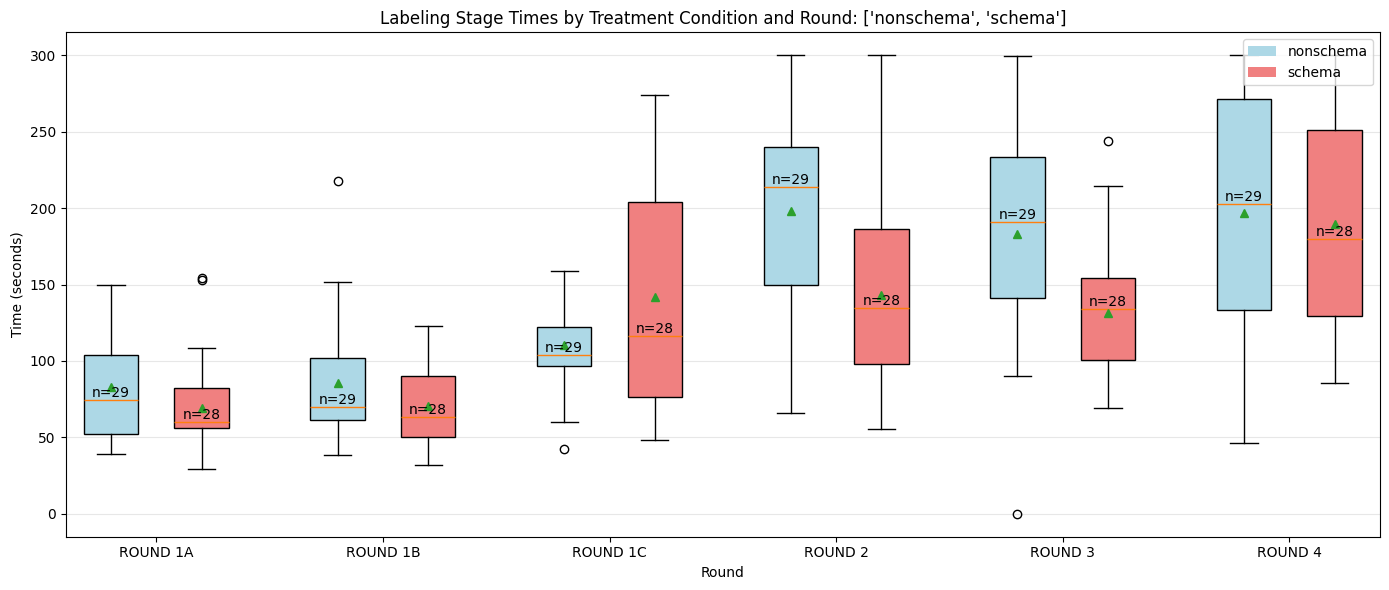

In [43]:
labeling_stage_time_cols = [col for col in data.columns if col.startswith("time_labeling_")]

use_conditions = ['nonschema', 'schema']

# Prepare data for box plot
# Melt the data to long format for easier plotting
plot_data = []
for col in labeling_stage_time_cols:
    for idx, row in data.iterrows():
        if row['treatment'] in use_conditions:
            plot_data.append({
                'round': col,
                'time': row[col],
                'condition': row['treatmentGroup']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = labeling_stage_time_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'labeling_1a' to 'Round 1a', etc.
    return col_name.replace('time_labeling_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['time'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Time (seconds)')
ax.set_title(f'Labeling Stage Times by Treatment Condition and Round: {use_conditions}')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['time']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.tight_layout()
plt.show()

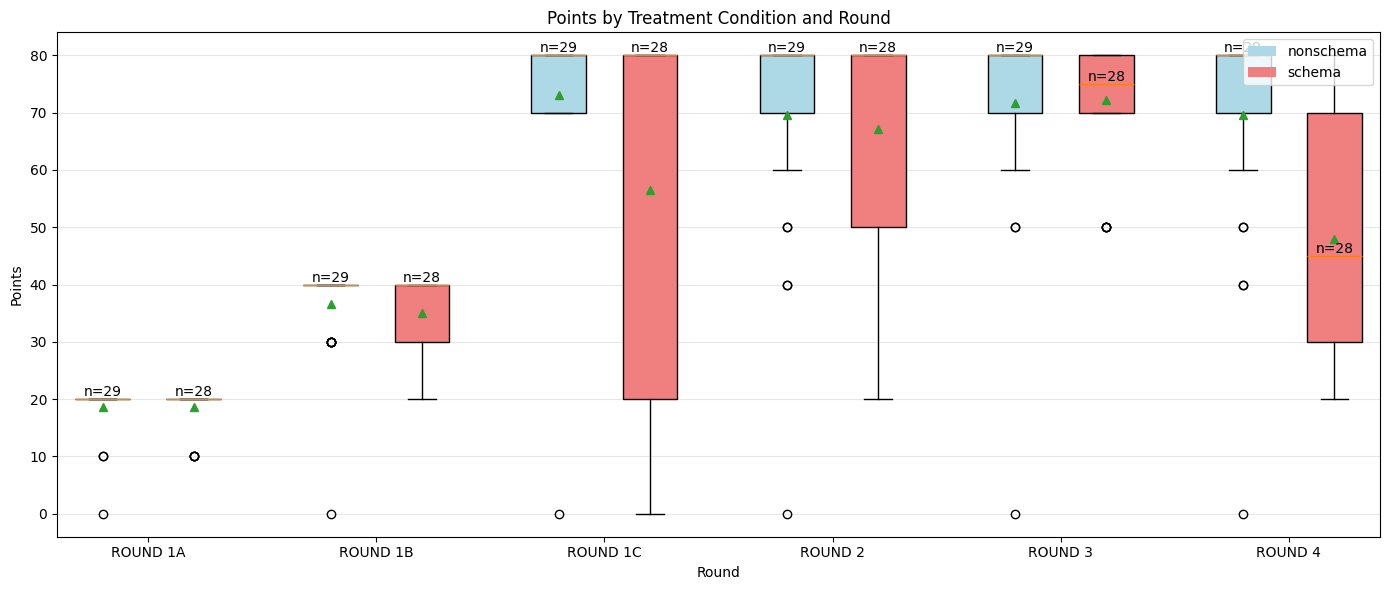

In [44]:
# Plot points by round instead of labeling time
points_cols = [col for col in data.columns if col.startswith("points_unique_")]

use_conditions = ['nonschema', 'schema']

# Prepare data for box plot
plot_data = []
for col in points_cols:
    for idx, row in data.iterrows():
        if row['treatment'] in use_conditions:
            plot_data.append({
                'round': col,
                'points': row[col],
                'condition': row['treatmentGroup']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = points_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'points_1a' to 'Round 1a', etc.
    return col_name.replace('points_unique_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['points'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Points')
ax.set_title('Points by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['points']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Plot scores by round instead of labeling time
score_cols = [col for col in data.columns if col.startswith('score_') and not col.startswith('score_with_recall_')]

# Prepare data for box plot
plot_data = []
for col in score_cols:
    for idx, row in data.iterrows():
        plot_data.append({
            'round': col,
            'score': row[col],
            'condition': row['treatmentGroup']
        })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = score_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'score_1a' to 'Round 1a', etc.
    return col_name.replace('score_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['score'].dropna()
        box_data.append(data_subset)

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Round')
ax.set_ylabel('Score (points/min)')
ax.set_title('Scores by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['score']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Plot total recall time by round
recall_time_cols = [col for col in data.columns if col.startswith('time_recall_total_')]

# Prepare data for box plot
plot_data = []
for col in recall_time_cols:
    for idx, row in data.iterrows():
        plot_data.append({
            'round': col,
            'recall_time': row[col],
            'condition': row['treatmentGroup']
        })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = recall_time_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'time_recall_total_1a' to 'Round 1a', etc.
    return col_name.replace('time_recall_total_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['recall_time'].dropna()
        box_data.append(data_subset)

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Round')
ax.set_ylabel('Total Recall Time (seconds)')
ax.set_title('Total Recall Time by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# Add n labels above each box
n_counts = plot_df.groupby(['round', 'condition']).count()['recall_time']
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        n = n_counts.get((round_name, condition), 0)
        pos = i * (len(conditions) + 0.5) + j
        y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
        ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import gzip

text = "big ponky\tbat ponky\tgun man\tcock\tgreen ponky\t3D\tbig mouth\tbig ear"
compressed = gzip.compress(text.encode('utf-8'))
print(f"Compressed size: {len(compressed)} bytes")

In [ ]:
labels.head().T

In [ ]:
label_bytes = pd.DataFrame()
for round in ["1c", "2", "3", "4"]:
    round_labels = data[[f"label_{round}_{i}" for i in range(8)]]
    combined = (round_labels.astype("str")+";").sum(axis=1)
    compressed = combined.apply(lambda x: gzip.compress(x.encode('utf-8')))
    label_bytes[round] = compressed.apply(lambda x: len(x))
    
label_bytes